In [1]:

import numpy as np
import matplotlib.pyplot  as plt
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv("sensor_data.csv",names=["temperature","humidity"])


In [2]:
df["Target"] = (df["humidity"] > 55.0).astype(int)
target_matrix=df["Target"]
design_matrix=df.drop(columns=["Target"])


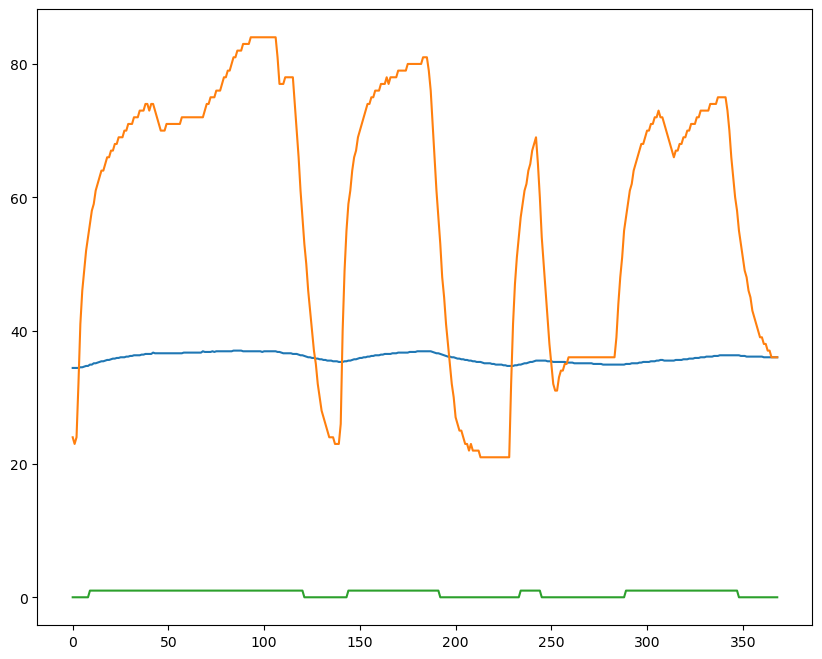

In [3]:
plt.figure(figsize=(10,8))
plt.plot(df)
plt.show()

In [4]:

design_matrix_train_, design_matrix_test, target_train, target_test = train_test_split(design_matrix, target_matrix, test_size=0.2, random_state=42)


In [5]:
test_mean=design_matrix_train_.mean()
test_std=design_matrix_train_.std()
print(f"the mean is {test_mean} \n and the std is {test_std}")
m=design_matrix_train_.shape[0]
design_matrix_train_ = (design_matrix_train_ - test_mean) / test_std
design_matrix_test = (design_matrix_test - test_mean) / test_std
design_matrix_train_.insert(0, "intercepts", 1)
design_matrix_test.insert(0, "intercepts", 1)
theta_matrix=np.zeros(design_matrix_train_.shape[1])


the mean is temperature    35.905424
humidity       58.115254
dtype: float64 
 and the std is temperature     0.687427
humidity       19.940053
dtype: float64


In [6]:
def sigmodoid(x):
    return 1/(1+np.exp(-x))

In [7]:
alpha=0.1
m=design_matrix_train_.shape[0]
print(f"the learning rate is {alpha} and m is {m}" )

the learning rate is 0.1 and m is 295


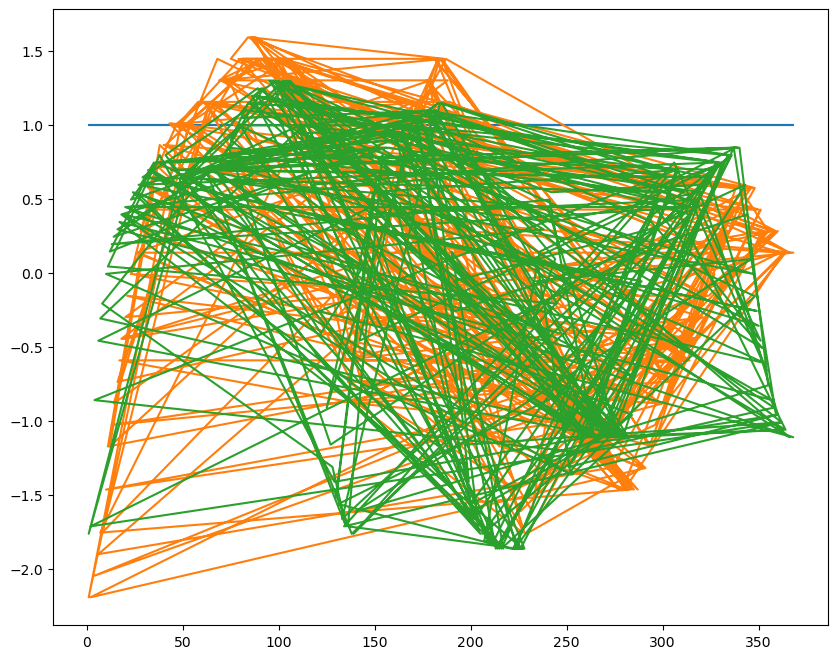

In [8]:
plt.figure(figsize=(10,8))
plt.plot(design_matrix_train_)
plt.show()

In [9]:
print(f"{design_matrix_train_.shape}\n{target_train.shape}\n{theta_matrix.shape}")
design_matrix_train_=design_matrix_train_.values


(295, 3)
(295,)
(3,)


In [10]:
def cost_function(m, cal, real):
    # We add a tiny epsilon (1e-15) to prevent log(0) which results in -infinity
    epsilon = 1e-15
    cal = np.clip(cal, epsilon, 1 - epsilon)
    return -1/m * np.sum(real * np.log(cal) + (1 - real) * np.log(1 - cal))

In [13]:
graphing=[]
for i in range(3000):
    predicted=design_matrix_train_.dot(theta_matrix)
    predicted=sigmodoid(predicted)
    graphing.append(cost_function(m,predicted,target_train))
    error=predicted-target_train
    new_theta=(design_matrix_train_.T.dot(error))*1/m
    theta_matrix=theta_matrix-alpha*new_theta
print(theta_matrix)

[ 1.09131399 -0.11106136  8.31125281]


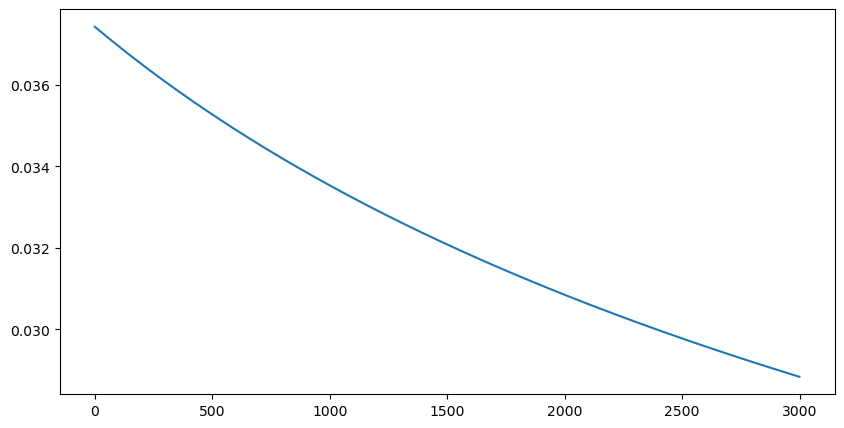

In [14]:
plt.figure(figsize=(10,5))
plt.plot(graphing)
plt.draw()

In [12]:
# 1. Convert the normalized test DataFrame into a raw NumPy array
design_matrix_test_v = design_matrix_test.values

# 2. Compute the linear combination for the test slice (X_test . theta)
z_test = design_matrix_test_v.dot(theta_matrix)

# 3. Map raw linear values to probabilities using your sigmoid function
test_probabilities = sigmodoid(z_test)

# 4. Apply the crisp classification decision threshold (>= 0.5 is Class 1, else 0)
test_predictions = (test_probabilities >= 0.5).astype(int)

# 5. Calculate raw classification accuracy
test_accuracy = np.mean(test_predictions == target_test)

print("\n" + "="*50)
print("             TEST SET EVALUATION             ")
print("="*50)
print(f"Final Model Test Accuracy: {test_accuracy * 100:.2f}%\n")


             TEST SET EVALUATION             
Final Model Test Accuracy: 98.65%

